# Exploratory Data Analysis — Customer Churn

Dataset: `data/processed/customer_features_2011-06-09_h183_validated.parquet` — 4,323 customers, 22 engineered features (Step 3), profiled for data quality (Step 4).

**Scope of this notebook.** Every plotting function and statistical test lives in [`src/eda.py`](../src/eda.py) — this notebook imports them and tells the analytical story. No plotting or test logic is defined inline, so the exact same functions can be reused by the dashboard (Step 15) without duplication.

Every number below is computed from the real feature table produced by the SQL pipeline. Nothing here is illustrative.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import eda
from src.data import quality as q
from src.config import PATHS

eda.set_style()
pd.set_option("display.max_columns", 40)

FEATURE_FILE = PATHS.data_processed / "customer_features_2011-06-09_h183_validated.parquet"
df = pd.read_parquet(FEATURE_FILE)
print(f"Loaded {len(df):,} customers x {df.shape[1]} columns from {FEATURE_FILE.name}")
df.head(3)

Loaded 4,323 customers x 28 columns from customer_features_2011-06-09_h183_validated.parquet


,customer_id,cutoff_date,recency_days,frequency,monetary_total,monetary_avg_order,tenure_days,active_days,avg_interpurchase_days,std_interpurchase_days,purchase_rate_per_month,total_items,avg_items_per_order,distinct_products,avg_unit_price,return_invoices,return_value,return_rate,orders_last_30d,orders_last_90d,spend_last_90d,spend_ratio_90d,country_name,is_uk,is_churned,avg_interpurchase_days_is_missing,std_interpurchase_days_is_missing,return_rate_raw
0,12346,2011-06-09,142,3,77352.96,25784.32,464,3,161.00,60.81,0.1968,74239,24746.33,25,1.0419,5,77621.14,1.0,0,0,0.00,0.0000,United Kingdom,True,True,False,False,1.0035
1,12347,2011-06-09,0,5,3529.27,705.85,221,5,55.25,14.93,0.6887,2141,428.20,101,1.6484,0,0.00,0.0,1,2,1018.77,0.2887,Iceland,False,False,False,False,0.0000
2,12348,2011-06-09,65,4,1388.40,347.10,255,4,63.33,20.82,0.4775,2488,622.00,24,0.5580,0,0.00,0.0,0,1,327.00,0.2355,Finland,False,False,False,False,0.0000


## 1. Target: churn rate and class imbalance

Churn is *defined*, not observed: a customer who bought in the 365 days before 2011-06-09 and made zero purchases in the 183 days after it. See [`config/config.yaml`](../config/config.yaml) and Step 3 of the README for the full definition and why this horizon was chosen over a shorter one.

,count,pct
is_churned,,
False,2485,57.48
True,1838,42.52


Imbalance ratio (majority:minority): 1.35:1


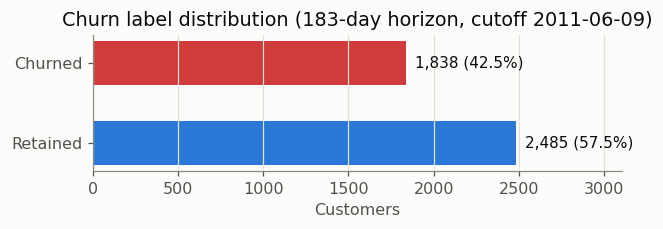

In [2]:
target = q.target_distribution(df["is_churned"])
display(target)
print(f"Imbalance ratio (majority:minority): {target.attrs['imbalance_ratio']}:1")
eda.plot_target_balance(df["is_churned"])
plt.show()

42.5% / 57.5% is a **mild** imbalance (1.35:1) — it does not call for SMOTE or undersampling. `class_weight="balanced"` is enough, and is what the baseline model (Step 7) will use.

## 2. Numerical variables

### Summary statistics

Reusing the same `numeric_summary` function from Step 4's data-quality module — one profiling implementation, not two.

In [3]:
NUMERIC_COLS = [
    "recency_days", "frequency", "monetary_total", "monetary_avg_order",
    "tenure_days", "active_days", "avg_interpurchase_days", "std_interpurchase_days",
    "purchase_rate_per_month", "total_items", "avg_items_per_order", "distinct_products",
    "avg_unit_price", "return_invoices", "return_value", "return_rate",
    "orders_last_30d", "orders_last_90d", "spend_last_90d", "spend_ratio_90d",
]
display(q.numeric_summary(df, NUMERIC_COLS))

,count,mean,std,min,25%,50%,75%,max,skew,n_negative,n_zero
recency_days,4323.0,129.576,102.817,0.000,31.000,106.000,213.000,364.00,0.402,0,76
frequency,4323.0,5.805,10.599,1.000,1.000,3.000,6.000,239.00,9.581,0,0
monetary_total,4323.0,2722.937,11784.500,2.900,376.420,904.180,2252.445,441293.98,23.069,0,0
monetary_avg_order,4323.0,384.708,626.134,2.900,189.175,295.150,430.220,25784.32,22.588,0,0
tenure_days,4323.0,347.715,160.873,0.000,226.000,364.000,494.000,555.00,-0.363,0,3
active_days,4323.0,5.198,8.225,1.000,1.000,3.000,6.000,166.00,8.217,0,0
avg_interpurchase_days,3192.0,93.594,76.815,1.000,41.752,72.230,120.000,540.00,1.859,0,0
std_interpurchase_days,2404.0,51.564,42.742,0.000,22.228,39.360,67.410,354.97,1.909,0,4
purchase_rate_per_month,4323.0,0.616,1.655,0.084,0.178,0.327,0.588,30.44,13.637,0,0
total_items,4323.0,1653.634,7268.488,1.000,200.000,507.000,1294.500,251823.00,18.536,0,0


### Numerical features vs. churn

Every feature below is tested with a **Mann-Whitney U test** rather than a t-test, because Step 4 already established these distributions are heavily right-skewed (skew up to 54 for `avg_items_per_order`) — Mann-Whitney compares distributions by rank and makes no normality assumption.

In [4]:
KEY_NUMERIC = [
    "recency_days", "frequency", "monetary_total", "tenure_days",
    "avg_interpurchase_days", "distinct_products", "return_rate",
    "spend_ratio_90d", "orders_last_90d", "purchase_rate_per_month",
]
test_results = pd.DataFrame([eda.mannwhitney_by_churn(df, c) for c in KEY_NUMERIC])
display(test_results)

,feature,median_retained,median_churned,u_stat,p_value,significant_at_0.01
0,recency_days,59.00,196.00,1226395.5,9.532539e-150,True
1,frequency,5.00,2.00,3407613.0,4.449070e-173,True
2,monetary_total,1534.46,511.90,3407680.0,6.010854e-169,True
3,tenure_days,423.00,302.50,2828864.0,3.619960e-41,True
4,avg_interpurchase_days,63.67,92.33,848135.5,1.966557e-31,True
5,distinct_products,67.00,28.00,3241384.5,3.250166e-123,True
6,return_rate,0.00,0.00,2709312.5,1.241950e-30,True
7,spend_ratio_90d,0.11,0.00,2953539.5,1.171546e-72,True
8,orders_last_90d,1.00,0.00,3209905.0,2.752358e-140,True
9,purchase_rate_per_month,0.44,0.22,3378542.5,2.088884e-160,True


All ten are significant at p < 0.01 — including after Bonferroni correction for testing ten features (adjusted alpha 0.001, and every p-value here is many orders of magnitude below that). The three largest median gaps:

- **`recency_days`**: 59 days (retained) vs 196 days (churned)
- **`frequency`**: 5 orders (retained) vs 2 orders (churned)
- **`monetary_total`**: £1,534 (retained) vs £512 (churned)

Box plots for the headline relationships (log scale where the skew would otherwise flatten the box):

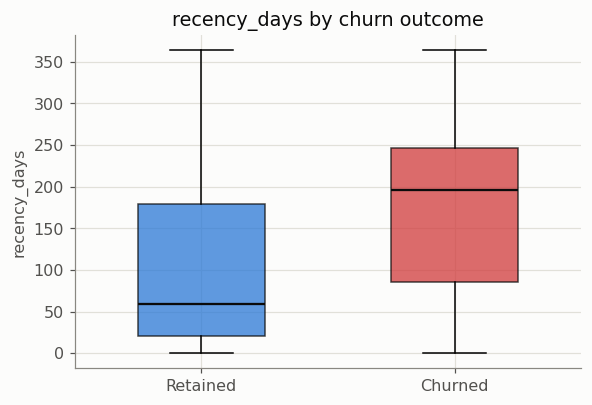

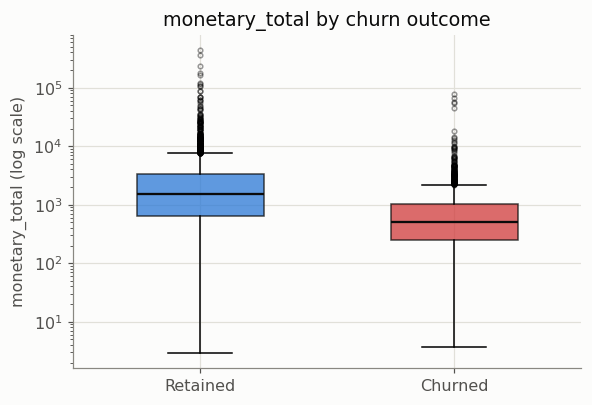

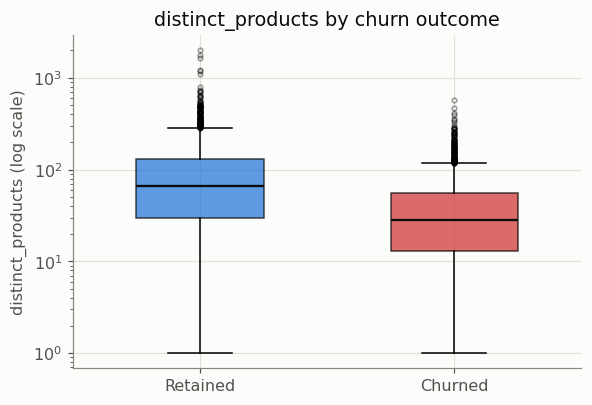

In [5]:
eda.plot_numeric_by_churn(df, "recency_days")
eda.plot_numeric_by_churn(df, "monetary_total", log_scale=True)
eda.plot_numeric_by_churn(df, "distinct_products", log_scale=True)
plt.show()

### Correlations

The correlation matrix over the RFM-style core (recency, frequency, monetary, tenure, activity) — useful for spotting redundant features before Step 6/7, not just for eyeballing.

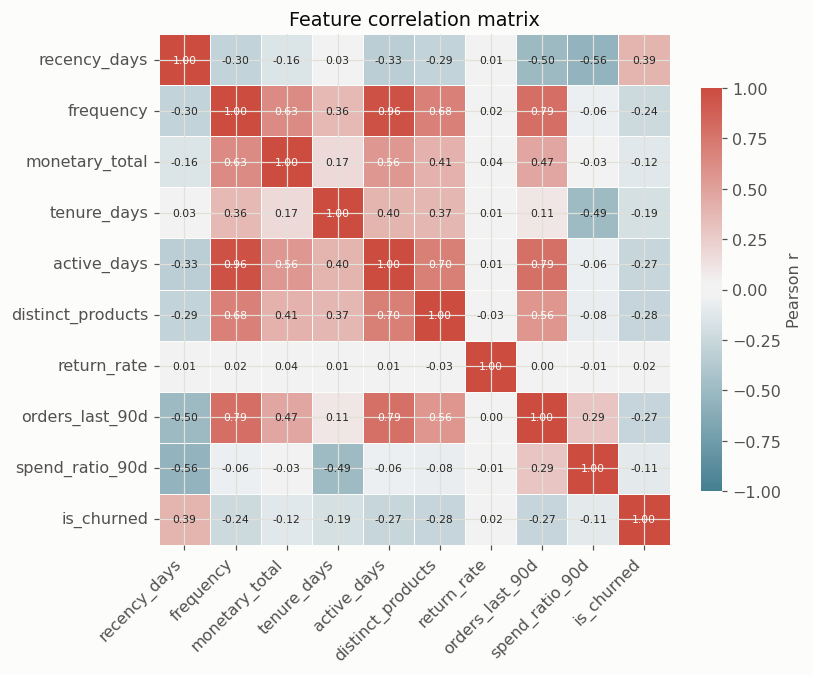

Pairs with |r| >= 0.9 (duplicate information):


,feature_a,feature_b,abs_corr
11,frequency,active_days,0.961348


In [6]:
CORR_COLS = [
    "recency_days", "frequency", "monetary_total", "tenure_days", "active_days",
    "distinct_products", "return_rate", "orders_last_90d", "spend_ratio_90d", "is_churned",
]
eda.plot_correlation_heatmap(df, CORR_COLS)
plt.show()

high_corr = q.highly_correlated_pairs(df, CORR_COLS, threshold=0.9)
print("Pairs with |r| >= 0.9 (duplicate information):")
display(high_corr)

## 3. Categorical variables

The only categorical feature this dataset supports is geography (`country_name` / `is_uk`) — there is no contract, payment-method, or demographic data in Online Retail II (documented in Step 2). 91.5% of customers are UK-based, so any country-level pattern outside the UK rests on small samples; category frequencies are shown alongside the rate for exactly that reason.

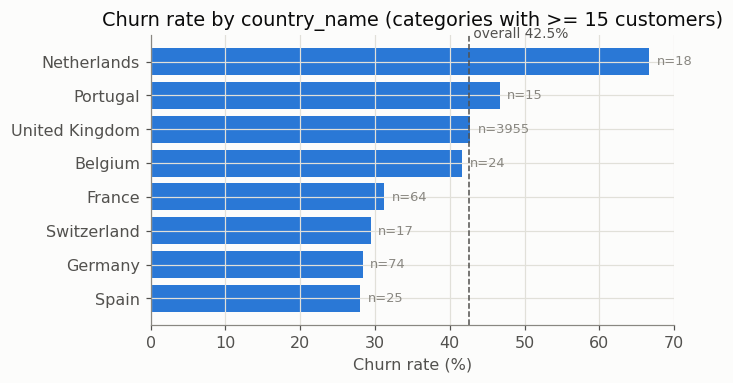

is_uk (binary UK vs. rest-of-world):
  feature  categories_tested  chi2  dof   p_value  significant_at_0.01
0   is_uk                  2  0.59    1  0.442802                False

country_name (categories with >= 15 customers, rest pooled to 'Other'):
        feature  categories_tested   chi2  dof   p_value  significant_at_0.01
0  country_name                  9  21.18    8  0.006677                 True


In [7]:
eda.plot_categorical_churn_rate(df, "country_name", min_count=15)
plt.show()

print("is_uk (binary UK vs. rest-of-world):")
print(pd.DataFrame([eda.chi2_by_churn(df, "is_uk")]))
print()
print("country_name (categories with >= 15 customers, rest pooled to 'Other'):")
print(pd.DataFrame([eda.chi2_by_churn(df, "country_name", min_count=15)]))

`is_uk` alone is **not** significant (p=0.44) — UK churn (42.7%) and rest-of-world churn (40.5%) are statistically indistinguishable. But the full `country_name` breakdown **is** significant (p=0.007): Germany, Spain and Switzerland sit meaningfully below the UK's rate, while the Netherlands sits well above it on only 18 customers. **That last figure is not reliable** — an 18-customer sample cannot support a country-specific retention policy — and is reported here as a hypothesis to revisit if the dataset grows, not a finding to act on.

## 4. Customer behaviour deep-dives

### Tenure vs. churn

Counter-intuitively, this is **non-monotonic** in the middle of the range.

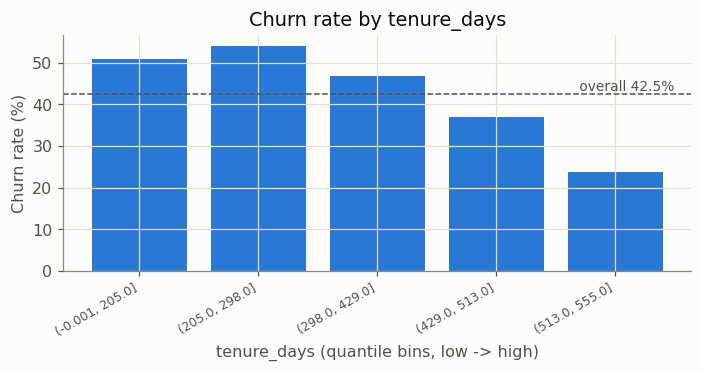

,churn_rate,n_customers
tenure_days,,
"(-0.001, 205.0]",0.510,869
"(205.0, 298.0]",0.540,866
"(298.0, 429.0]",0.468,866
"(429.0, 513.0]",0.369,859
"(513.0, 555.0]",0.238,863


In [8]:
_, table = eda.plot_binned_churn_rate(df, "tenure_days", bins=5)
plt.show()
display(table)

Churn rises from the shortest-tenure bin (51.0%) to the second bin (54.0%) before falling steadily to 23.8% in the longest-tenure bin. This is very likely a **new-customer risk shape rather than a pure tenure effect**: the shortest-tenure group includes customers who joined right before the cutoff and simply have not had time to re-order yet within the observation window, which inflates their apparent churn. Established customers (tenure > 429 days) churn far less — consistent with the frequency/recency findings above, since tenure and order count are related.

### Spend vs. churn

Already shown to be significant (Mann-Whitney, p ≈ 6e-169). The quintile view shows how strongly monotonic it is:

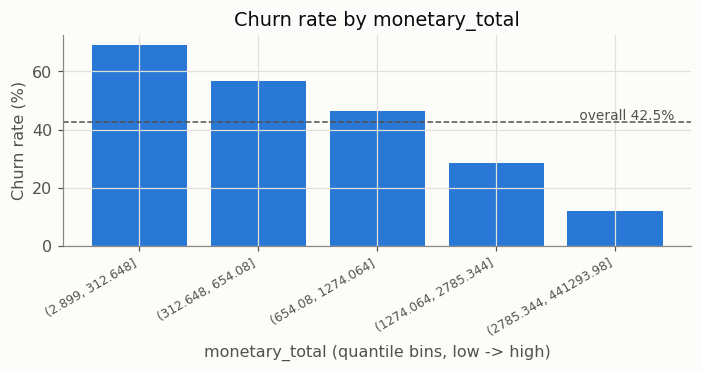

,churn_rate,n_customers
monetary_total,,
"(2.899, 312.648]",0.691,865
"(312.648, 654.08]",0.568,864
"(654.08, 1274.064]",0.464,865
"(1274.064, 2785.344]",0.284,864
"(2785.344, 441293.98]",0.119,865


In [9]:
_, table = eda.plot_binned_churn_rate(df, "monetary_total", bins=5)
plt.show()
display(table)

A clean, monotonic gradient: 69.1% churn in the lowest-spend quintile down to 11.9% in the highest. This is exactly the relationship the CLV × churn retention-priority score (Step 12) will exploit — the customers most likely to churn are disproportionately the ones worth the least to retain, and the two signals need to be combined rather than acted on separately.

### Product diversity ("service usage") vs. churn

Online Retail II has no service/subscription concept, so `distinct_products` purchased is the closest available proxy for engagement breadth.

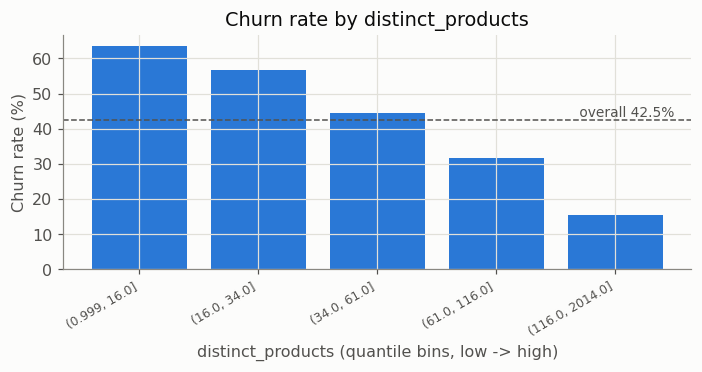

,churn_rate,n_customers
distinct_products,,
"(0.999, 16.0]",0.636,878
"(16.0, 34.0]",0.566,881
"(34.0, 61.0]",0.445,836
"(61.0, 116.0]",0.317,867
"(116.0, 2014.0]",0.156,861


In [10]:
_, table = eda.plot_binned_churn_rate(df, "distinct_products", bins=5)
plt.show()
display(table)

Another clean gradient: 63.6% in the least-diverse quintile to 15.6% in the most-diverse. Customers who explore the catalogue more broadly are much less likely to lapse.

### Recent engagement vs. churn

`spend_ratio_90d` (share of lifetime spend that happened in the last 90 days pre-cutoff) is a direct trend signal — did this customer just go quiet?

In [11]:
recent = df.assign(has_recent_spend=df["spend_ratio_90d"] > 0).groupby("has_recent_spend")["is_churned"].agg(["mean", "size"])
recent.columns = ["churn_rate", "n_customers"]
display(recent.round(3))

returned = df.assign(has_return=df["return_invoices"] > 0).groupby("has_return")["is_churned"].agg(["mean", "size"])
returned.columns = ["churn_rate", "n_customers"]
display(returned.round(3))

,churn_rate,n_customers
has_recent_spend,,
False,0.583,2350
True,0.237,1973


,churn_rate,n_customers
has_return,,
False,0.527,2388
True,0.299,1935


Two more large, unambiguous gaps:

- **No purchase in the last 90 days pre-cutoff: 58.3% churn. At least one: 23.7%.** The single strongest behavioural signal after recency itself — and closely related to it, since both describe recent inactivity.
- **Customers who never returned an item: 52.7% churn. Customers who returned at least once: 29.9%.** Initially counter-intuitive — a return looks like a complaint — but it makes sense here: issuing a return requires an active, ongoing purchasing relationship, and the customers with zero returns are disproportionately the low-frequency, one-and-done buyers who were always more likely to lapse. This is a correlation with engagement level, not evidence that returns *cause* retention.

## Key Data Science Findings

1. **Churn is well-defined and moderately imbalanced.** 42.5% churned / 57.5% retained (1.35:1) at the 183-day horizon — mild enough that class weighting, not resampling, is the right tool.
2. **Recency is the single strongest univariate signal.** Median 59 days (retained) vs. 196 days (churned); the churn rate climbs from 16% to 69% across recency quintiles (Step 4). It is legitimate — computed strictly pre-cutoff — not leakage.
3. **Monetary value shows a clean, near-linear gradient with churn**: 69.1% churn in the bottom spending quintile down to 11.9% in the top. Value and risk are strongly (inversely) related, which is exactly why Step 12's retention-priority score needs to combine them rather than rank on churn probability alone.
4. **Recent activity (last 90 days) separates customers more sharply than lifetime totals do.** 58.3% vs. 23.7% churn by presence/absence of a purchase in the trailing quarter — a customer's trajectory matters as much as their history.
5. **Product/category breadth is protective.** Churn falls from 63.6% (bottom quintile of distinct products bought) to 15.6% (top quintile) — customers who explore more of the catalogue are stickier.
6. **Tenure's relationship with churn is non-monotonic, not linear.** Churn is highest in the second-shortest tenure bin (54.0%), not the very shortest (51.0%) — consistent with new customers not yet having had a fair chance to re-order inside the observation window, a distinct phenomenon from genuine long-term disengagement.
7. **Returning an item is associated with LOWER churn (29.9% vs. 52.7%).** Read as an engagement-level correlation, not a causal effect of returns — see the note above.
8. **`frequency` and `active_days` are near-duplicate information (r = 0.961)** — expected, since most customers place at most one order per active day. Worth resolving before a coefficient-based model (Step 7), not necessarily before a tree-based one (Step 8).
9. **Country is a weak signal, and mostly a UK dataset.** `is_uk` alone is not significant (p = 0.44); the full country breakdown is (p = 0.007), but 91.5% of customers are UK-based and most non-UK countries have samples too small (< 25 customers) to support country-specific policy.
10. **Every numeric feature tested (10/10) differs significantly between churned and retained customers** (Mann-Whitney, p < 0.001 even after Bonferroni correction) — the engineered feature set from Step 3 is not noise; there is real, multi-faceted signal for a model to learn from.

## Modelling Implications

- **Class weighting, not resampling.** The 1.35:1 imbalance is mild; `class_weight="balanced"` in Step 7's Logistic Regression baseline and Step 8's tree ensembles is sufficient.
- **Log-transform monetary and count features for the linear baseline.** `monetary_total`, `total_items`, `avg_items_per_order` and similar features have skew above 15–50; a linear model will need a `log1p` transform (or a `PowerTransformer`) where a tree-based model (Step 8) will not.
- **Drop or combine `frequency`/`active_days` for the linear model.** Their 0.961 correlation will inflate coefficient variance in Logistic Regression; tree-based models split on one and ignore the other, so this matters far less there.
- **Treat `recency_days` as expected to dominate feature importance — not as a bug.** When Step 11's SHAP analysis shows it at the top, that will corroborate this EDA, not contradict it. The task is to check that no *other* feature is leaking, using `recency_days`'s legitimately-high importance as the baseline for what "strong but not suspicious" looks like.
- **The non-monotonic tenure relationship argues against feeding raw `tenure_days` alone into a linear model** without a transformation (e.g. a spline, or binning) that can represent the rise-then-fall shape a single linear coefficient cannot.
- **Churn probability and customer value are both needed for Step 12** — they move in opposite directions with several of the same features (monetary_total, distinct_products), so a policy built on churn probability alone would over-prioritise low-value customers who were always likely to lapse.
- **No demographic, contract or payment-method features exist to add.** The feature set is behavioural/transactional by necessity — this should be stated plainly in the final README (Step 22) rather than implied.